מגישים:

יובל גלולה - 206159345

ירין ערבה - 207860206

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
print("Torch GPU:", torch.cuda.is_available())
print("Torch device:", torch.cuda.get_device_name(0))

Torch GPU: True
Torch device: NVIDIA GeForce RTX 4070 SUPER


# Part A

In [33]:
import keras
from keras import layers
# import tensorflow_datasets as tfds
# import tensorflow as tf               # Not needed since we are using Keras with PyTorch backend
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import json # for saving results in json format

#### Load Data 'CIFAR10'

In [4]:
from torchvision import datasets # needed for loading the cifar10 dataset

# Load the training dataset
train_dataset = datasets.CIFAR10(
    root="./train",
    train=True,
    download=True
)
X_train = np.array(train_dataset.data)
y_train = np.array(train_dataset.targets)

# Load the test dataset
test_dataset = datasets.CIFAR10(
    root="./test",
    train=False,
    download=True
)
X_test = np.array(test_dataset.data)
y_test = np.array(test_dataset.targets)

Files already downloaded and verified


c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


#### ===Helpers===

In [ ]:
# Display some random sample images from the training dataset along with their labels
def show_images(ds, num_images=6):
    class_names = ds.classes # Get the class names from the dataset

    plt.figure(figsize=(12,5))
    for i in range(num_images):
        idx = np.random.randint(0, len(ds))
        img, label = ds[idx]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label} ({class_names[label]})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# plot history function to plot training and validation accuracy and loss curves for a given model
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(model_name + ' - Train & Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(model_name + ' - Train & Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
    

# Function to load results from a file and convert to a DataFrame for analysis
def load_results(file, model_name):
    # Load results from a JSON file
    with open(file, "r") as f:
        data = json.load(f)
        
    # Store results in a list of dicts
    rows = []

    for r in data:
        cfg = r["config"]

        rows.append({
            "model": model_name,
            "filters": cfg["filters"],
            "kernel": cfg["kernel"],
            "dropout": cfg["dropout"],
            "dense": cfg["dense"],
            "train_acc": r["accuracy"][-1],
            "val_acc": r["val_accuracy"][-1],
            "train_loss": r["loss"][-1],
            "val_loss": r["val_loss"][-1],
            "history": r
        })

    return pd.DataFrame(rows)

#### Data Examine:

Shape of the Training & Test datasets:

In [5]:
# Print the shapes of the training and test datasets
print("Training data shape:" + str(X_train.shape) + ", " + str(y_train.shape))
print("Test data shape:" + str(X_test.shape) + ", " + str(y_test.shape))

Training data shape:(50000, 32, 32, 3), (50000,)
Test data shape:(10000, 32, 32, 3), (10000,)


Every image is 32x32 RGB.

Label names:

In [21]:
class_names = train_dataset.classes # Get the class names from the dataset
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Distribution of classes in the training dataset:

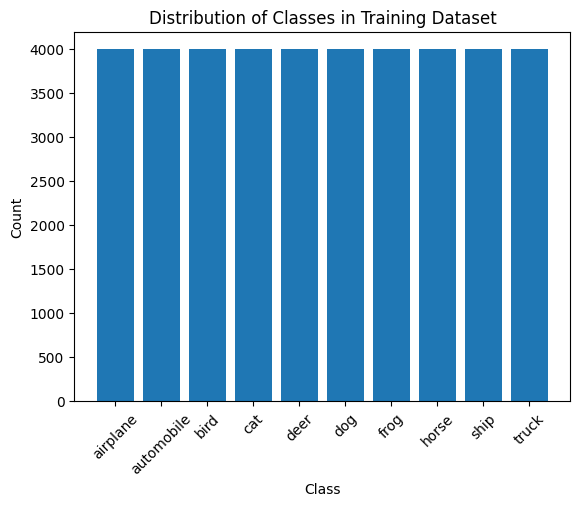

In [22]:
# display the distribution of classes in the training dataset
class_counts = Counter(y_train)
num_classes = len(class_names)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.title("Distribution of Classes in Training Dataset")
plt.show()

Data is distributed equally.

next we'll show some random images and their labels:

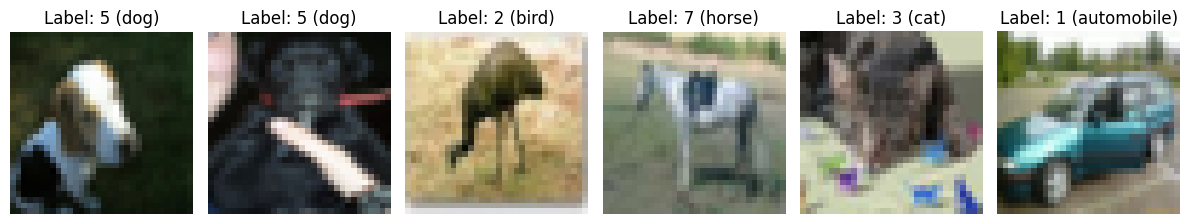

In [8]:
# Display some random sample images from the training dataset along with their labels
show_images(train_dataset)

### CNN Training

define variables:

In [14]:
CIFAR10_IMG_SIZE = (X_train.shape[1], X_train.shape[2])
Large_BATCH_SIZE = 128
Small_BATCH_SIZE = 64
Short_EPOCHS = 5
Long_EPOCHS = 20

In [15]:
# Split the training dataset into training and validation sets (80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

#### CNN With Data Augmentation

In [99]:
augmentation = keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=0.1),
    layers.RandomZoom(height_factor=0.1)
])

In [105]:
# Build a simple CNN model with 1 hidden layer
def build_cnn_1hidden(filters=32, kernel=3, dropout=0.3, dense_units=128):

    inputs = keras.Input(shape=(CIFAR10_IMG_SIZE[0], CIFAR10_IMG_SIZE[1], 3))
    x = augmentation(inputs)

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build a simple CNN model with 2 hidden layer
def build_cnn_2hidden(filters=32, kernel=3, dropout=0.3, dense_units=128):

    inputs = keras.Input(shape=(CIFAR10_IMG_SIZE[0], CIFAR10_IMG_SIZE[1], 3))
    x = augmentation(inputs)

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Build a simple CNN model with 3 hidden layer
def build_cnn(filters=32, kernel=3, dropout=0.3, dense_units=128):

    inputs = keras.Input(shape=(CIFAR10_IMG_SIZE[0], CIFAR10_IMG_SIZE[1], 3))
    x = augmentation(inputs)

    x = layers.Conv2D(filters, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(filters*4, kernel, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [106]:
configs = [
    {"filters":32, "kernel":3, "dropout":0.5, "dense":128},
    {"filters":32, "kernel":3, "dropout":0.3, "dense":128},
    {"filters":32, "kernel":3, "dropout":0.5, "dense":256},
    {"filters":32, "kernel":3, "dropout":0.3, "dense":256},
    {"filters":64, "kernel":3, "dropout":0.5, "dense":128},
    {"filters":64, "kernel":3, "dropout":0.3, "dense":128},
    {"filters":64, "kernel":3, "dropout":0.5, "dense":256},
    {"filters":64, "kernel":3, "dropout":0.3, "dense":256},
]

#### HyperParameters Examine:

Examine 8 configurations of ***1*** hidden layer models:

In [108]:
import json

# File to store results in
RESULTS_FILE = "cnn_1hidden_config_results.json"

# Load previous results if exist
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# internal function to check if a config has already been evaluated
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


for cfg in configs:

    if config_exists(cfg):
        print("Skipping existing config:", cfg)
        continue

    model = build_cnn_1hidden(
        filters=cfg["filters"],
        kernel=cfg["kernel"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val
    }

    results.append(result)

    # Save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(cfg, "->", best_val)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 162s 814ms/step - accuracy: 0.1595 - loss: 2.2135 - val_accuracy: 0.1988 - val_loss: 2.0941
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 183s 915ms/step - accuracy: 0.2005 - loss: 2.1028 - val_accuracy: 0.2402 - val_loss: 2.0439
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 187s 936ms/step - accuracy: 0.2251 - loss: 2.0525 - val_accuracy: 0.2647 - val_loss: 1.9812
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 186s 929ms/step - accuracy: 0.2464 - loss: 2.0076 - val_accuracy: 0.2942 - val_loss: 1.9364
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 187s 936ms/step - accuracy: 0.2558 - loss: 1.9746 - val_accuracy: 0.3039 - val_loss: 1.9088
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 186s 933ms/step - accuracy: 0.2647 - loss: 1.9431 - val_accuracy: 0.3047 - val_loss: 1.8798
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 188s 938ms/step - accuracy: 0.2801 - loss: 1.9180 - val_accuracy: 0.2983 - val_loss: 1.8812
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 188s 939ms/step - accuracy: 0.2875 -

Examine 8 configurations of ***2*** hidden layer models:

In [109]:
import json

# File to store results in
RESULTS_FILE = "cnn_2hidden_config_results.json"

# Load previous results if exist
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# internal function to check if a config has already been evaluated
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


for cfg in configs:

    if config_exists(cfg):
        print("Skipping existing config:", cfg)
        continue

    model = build_cnn_2hidden(
        filters=cfg["filters"],
        kernel=cfg["kernel"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val
    }

    results.append(result)

    # Save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(cfg, "->", best_val)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 68s 340ms/step - accuracy: 0.1871 - loss: 2.1398 - val_accuracy: 0.2625 - val_loss: 1.9681
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 71s 353ms/step - accuracy: 0.2512 - loss: 1.9705 - val_accuracy: 0.2959 - val_loss: 1.9017
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 71s 353ms/step - accuracy: 0.2721 - loss: 1.9082 - val_accuracy: 0.3178 - val_loss: 1.8250
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 70s 348ms/step - accuracy: 0.2970 - loss: 1.8483 - val_accuracy: 0.3259 - val_loss: 1.7851
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 343ms/step - accuracy: 0.3117 - loss: 1.8108 - val_accuracy: 0.3433 - val_loss: 1.7841
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 364ms/step - accuracy: 0.3265 - loss: 1.7856 - val_accuracy: 0.3462 - val_loss: 1.7365
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 72s 362ms/step - accuracy: 0.3330 - loss: 1.7564 - val_accuracy: 0.3745 - val_loss: 1.6794
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 70s 348ms/step - accuracy: 0.3442 - loss: 1

Examine 8 configurations of ***3*** hidden layer models:

In [ ]:
import json

# File to store results in
RESULTS_FILE = "cnn_3hidden_config_results.json"

# Load previous results if exist
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# internal function to check if a config has already been evaluated
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


for cfg in configs:

    if config_exists(cfg):
        print("Skipping existing config:", cfg)
        continue

    model = build_cnn(
        filters=cfg["filters"],
        kernel=cfg["kernel"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val
    }

    results.append(result)

    # Save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(cfg, "->", best_val)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 365ms/step - accuracy: 0.2037 - loss: 2.0834 - val_accuracy: 0.2883 - val_loss: 1.9201
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 71s 355ms/step - accuracy: 0.2826 - loss: 1.8898 - val_accuracy: 0.3203 - val_loss: 1.8247
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 72s 359ms/step - accuracy: 0.3378 - loss: 1.7748 - val_accuracy: 0.3367 - val_loss: 1.8164
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 370ms/step - accuracy: 0.3787 - loss: 1.6844 - val_accuracy: 0.3947 - val_loss: 1.6618
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 367ms/step - accuracy: 0.3982 - loss: 1.6270 - val_accuracy: 0.4575 - val_loss: 1.5126
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 370ms/step - accuracy: 0.4186 - loss: 1.5815 - val_accuracy: 0.4386 - val_loss: 1.5127
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 364ms/step - accuracy: 0.4374 - loss: 1.5418 - val_accuracy: 0.4594 - val_loss: 1.4585
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 76s 380ms/step - accuracy: 0.4477 - loss: 1

Load the 3 architecture files

In [47]:
df1 = load_results("cnn_1hidden_config_results.json", "1 hidden")
df2 = load_results("cnn_2hidden_config_results.json", "2 hidden")
df3 = load_results("cnn_3hidden_config_results.json", "3 hidden")

top 2 configs of each file(1,2,3 hidden layers)

In [48]:
top1hidden = df1.sort_values("val_acc", ascending=False).head(2)
top2hidden = df2.sort_values("val_acc", ascending=False).head(2)
top3hidden = df3.sort_values("val_acc", ascending=False).head(2)

Combine them and sort by the **`validation accuracy`**:

In [49]:
top_models = pd.concat([top1hidden, top2hidden, top3hidden])

top_models = top_models.sort_values("val_acc", ascending=False)

top_models.drop(["history"], inplace=False, axis=1)

,model,filters,kernel,dropout,dense,train_acc,val_acc,train_loss,val_loss
6,3 hidden,64,3,0.5,256,0.639805,0.658125,1.019790,0.970262
7,3 hidden,64,3,0.3,256,0.644766,0.654844,0.998462,1.019971
6,2 hidden,64,3,0.5,256,0.493945,0.532344,1.405543,1.296691
7,2 hidden,64,3,0.3,256,0.503945,0.507969,1.372203,1.357699
7,1 hidden,64,3,0.3,256,0.356133,0.360625,1.706052,1.715358
5,1 hidden,64,3,0.3,128,0.335742,0.358438,1.761616,1.708207


Plot the training curves:

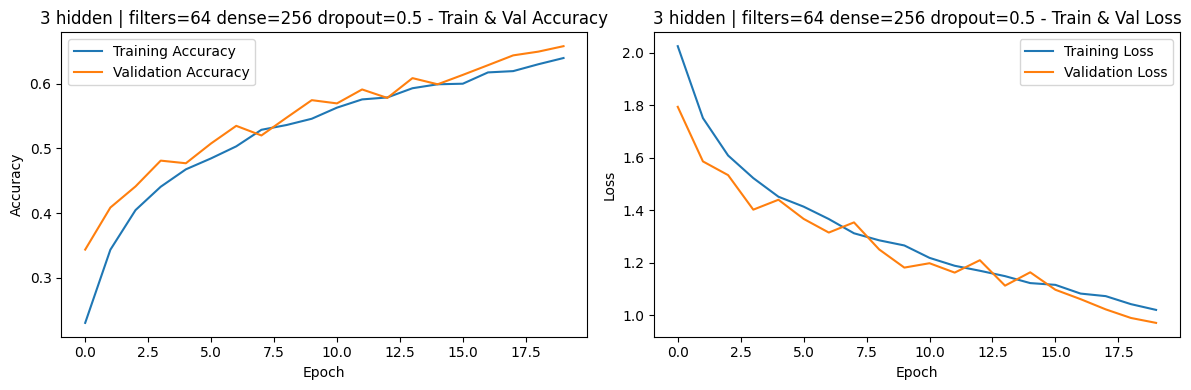

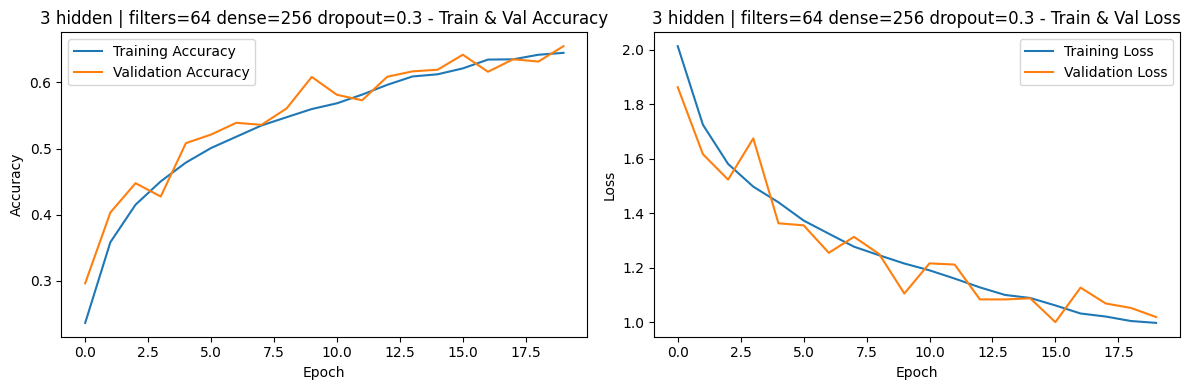

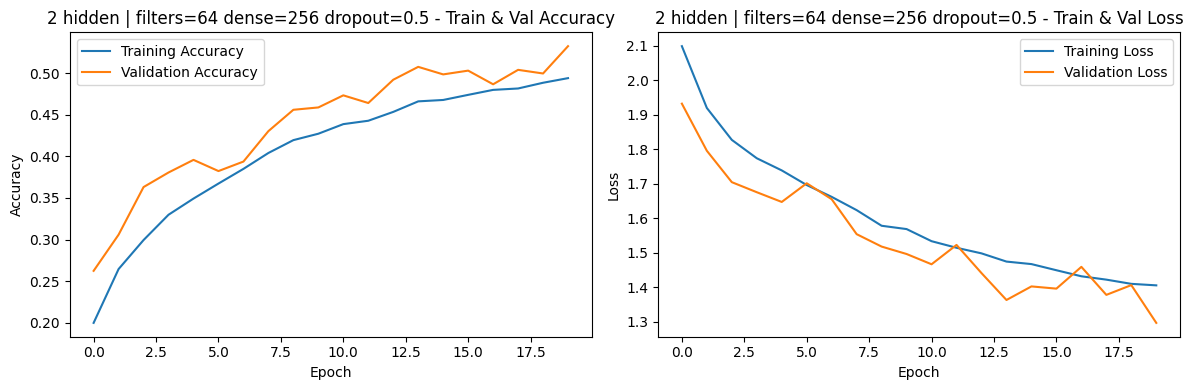

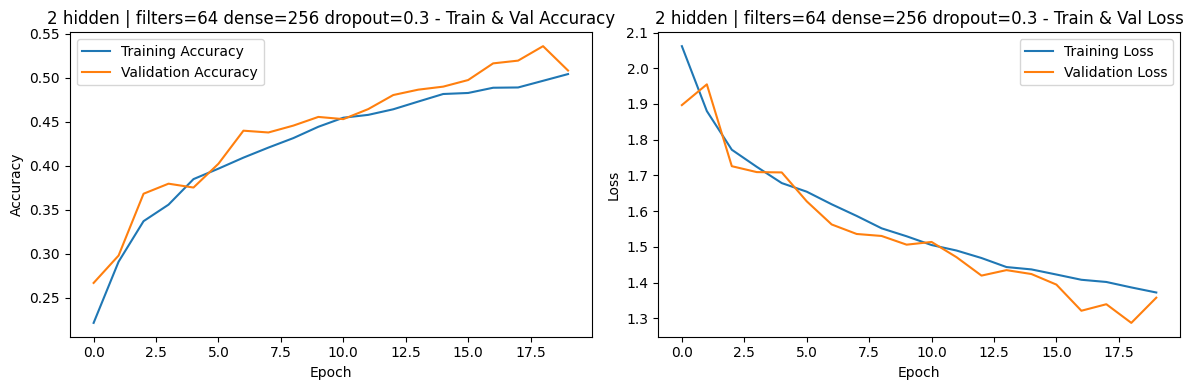

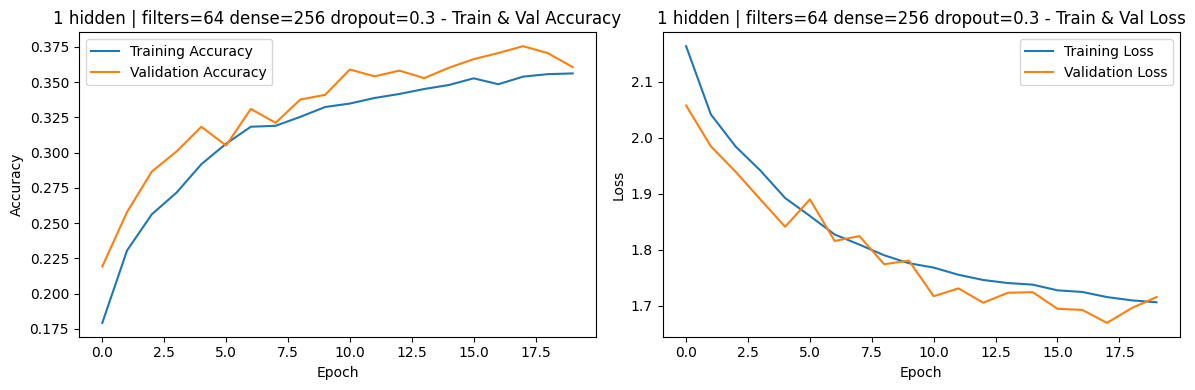

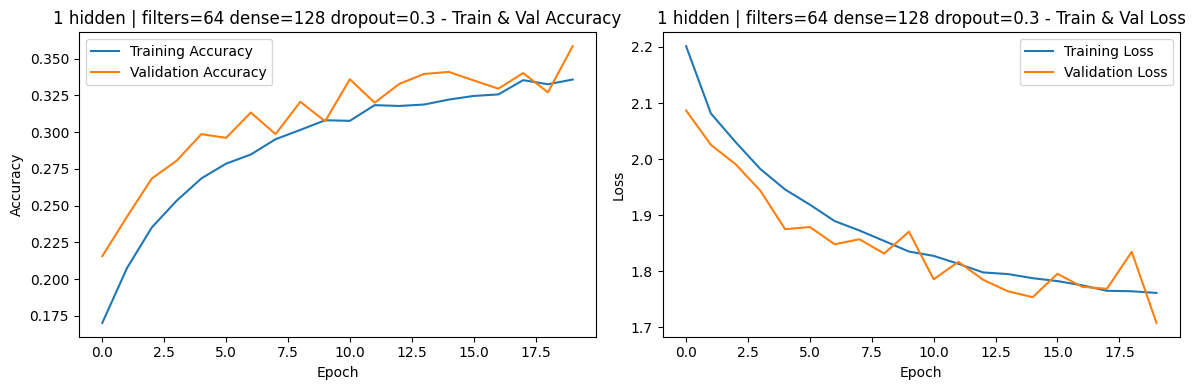

In [50]:
class HistoryWrapper:
    def __init__(self, history_dict):
        self.history = history_dict

for _, row in top_models.iterrows():

    name = (
        f"{row['model']} | "
        f"filters={row['filters']} "
        f"dense={row['dense']} "
        f"dropout={row['dropout']}"
    )

    plot_history(HistoryWrapper(row["history"]), name)

**Conclusions for the top 2 configs of each model used 1,2,3 hidden layers:**
1. 3 layers got the highest train&validation accuracies, lowest train&validation loss. more restrained from overfitting while using higher dropout.
2. seems like the models can train for more, the curves still go up/down.
3. the dataset is complex so we need the right models to deal with it. furthermore, we can see that we might get even better accuracy if we'll make more complex models, more layers... it make sense because making more layers will assemble complicated patterns like dog ear, airplane wing etc..

eventually, theres alot of modifies and changes some can make for better results, we decided to work with the first model as out top and continue to the next part of the task.

In [127]:
best_model = top_models.iloc[0]

best_model

model                                                  3 hidden
filters                                                      64
kernel                                                        3
dropout                                                     0.5
dense                                                       256
train_acc                                              0.639805
val_acc                                                0.658125
train_loss                                              1.01979
val_loss                                               0.970262
history       {'config': {'filters': 64, 'kernel': 3, 'dropo...
Name: 6, dtype: object

Train our best cfg for 40 epochs:

In [ ]:
RESULTS_FILE = "cnn_best_cfg_results.json"

# best configuration selected
best_cfg = {
    "filters": int(best_model["filters"]),
    "kernel": int(best_model["kernel"]),
    "dropout": float(best_model["dropout"]),
    "dense": int(best_model["dense"])
}

# Load previous results
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r") as f:
        results = json.load(f)
else:
    results = []

# check if this config already exists
def config_exists(cfg):
    for r in results:
        if r["config"] == cfg:
            return True
    return False


if config_exists(best_cfg):
    print("Skipping existing config:", best_cfg)

else:
    print("Training best configuration:", best_cfg)

    model = build_cnn(
        filters=best_cfg["filters"],
        kernel=best_cfg["kernel"],
        dropout=best_cfg["dropout"],
        dense_units=best_cfg["dense"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=Large_BATCH_SIZE
    )
    # Save the best model weights
    model.save_weights("best_model.weights.h5")
    model.summary()
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Final test accuracy:", test_acc)
    print("Final test loss:", test_loss)

    best_val = max(history.history["val_accuracy"])

    result = {
        "config": best_cfg,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val,
        "test_acc": test_acc,
        "test_loss": test_loss
    }

    results.append(result)

    # save results immediately
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=4)

    print(best_cfg, "->", best_val)

Training best configuration: {'filters': 64, 'kernel': 3, 'dropout': 0.5, 'dense': 256}
Epoch 1/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 454ms/step - accuracy: 0.1971 - loss: 2.1018 - val_accuracy: 0.2161 - val_loss: 1.9721
Epoch 2/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 51s 397ms/step - accuracy: 0.2750 - loss: 1.9004 - val_accuracy: 0.3364 - val_loss: 1.7784
Epoch 3/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 394ms/step - accuracy: 0.3446 - loss: 1.7564 - val_accuracy: 0.3909 - val_loss: 1.6454
Epoch 4/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 388ms/step - accuracy: 0.3812 - loss: 1.6726 - val_accuracy: 0.4194 - val_loss: 1.5555
Epoch 5/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 52s 406ms/step - accuracy: 0.4080 - loss: 1.5983 - val_accuracy: 0.4292 - val_loss: 1.5587
Epoch 6/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 52s 405ms/step - accuracy: 0.4307 - loss: 1.5532 - val_accuracy: 0.4502 - val_loss: 1.5132
Epoch 7/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 50s 394ms/step - accuracy: 0.4526 - loss: 1.4925 - val_accuracy: 0.4888 - val_loss: 1.

Model: "functional_95"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_99 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_279 (Conv2D)             │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_258               │ (None, 16, 16, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_280 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_259               │ (None, 8, 8, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_281 (Conv2D)             │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_260               │ (None, 4, 4, 256)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_41     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,536 (5.03 MB)

 Trainable params: 439,178 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 878,358 (3.35 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6376 - loss: 1.0642
Final test accuracy: 0.6376000046730042
Final test loss: 1.0642129182815552
{'filters': 64, 'kernel': 3, 'dropout': 0.5, 'dense': 256} -> 0.6669921875


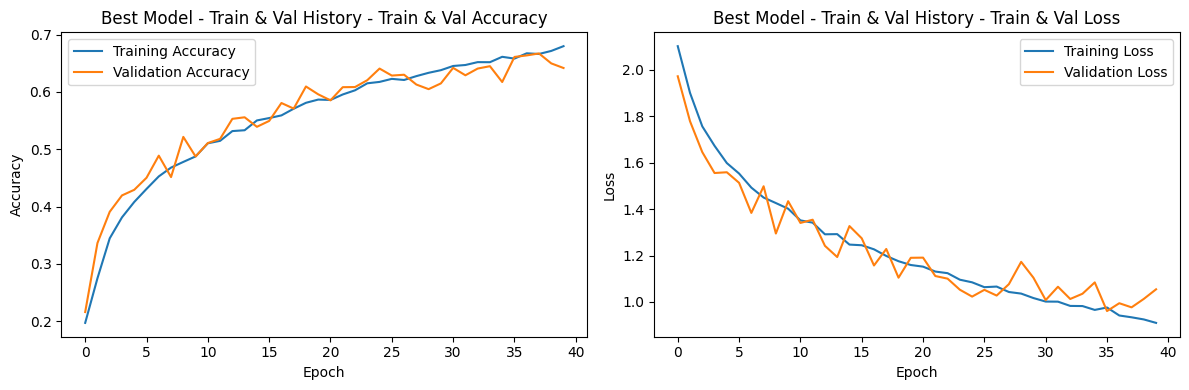

In [51]:
# load the best model weights and plot history
with open("cnn_best_cfg_results.json", "r") as f:
    data = json.load(f)

plot_history(HistoryWrapper(data[-1]), "Best Model - Train & Val History")


### Transfer Learning

**`ResNet50`** - a 50 learning layers model using **residual learning**, where **skip connections** allow layers to learn the residual mapping between input and output.

**`MobileNetV2`**- a 17 learning layers model using **invert residual blocks** -> instead of traditional residual blocks that connect layers of the same depth, inverted residual blocks connect layers with different depths which help reducing computational complexity. use also **MBConv** blocks.

**`VGG16`**- a simple 16 learning layers CNN architecture, organized into blocks, with each block containing multiple convolutional layers followed by a max-pooling layer.

**`EfficientNetB0`**- a CNN architecture uses scaling to balance network depth, width, and input resolution. use also **MBConv** blocks.

1) *Residual Learning* learns the difference (residual) between the input and the desired output instead of learning the full transformation.

2) *skip connections* are shortcuts that allow information to bypass one or more layers and be added directly to a later layer, effectively preserving important information from earlier layers.

3) *invert residual blocks* connections are made between thin layers instead of wide layers, This design reduces computational cost.

4) *MBConv* include a structure of expansion layer which expands the number of channels(feature space). Depthwise convolution which apply each filter on one channel. SE which focus the useful parameters. Projection layer which reduce the channels again. skip connection to preserve important information.

**each model has a preprocess input:**
1. **`MobileNetV2`** preprocess is to center the data around 0 by divide the input pixel's with 127.5 and then subtract 1.
2. **`VGG16`** and **`ResNet50`** preprocess is to match dataset color distribution to ImageNet by convert RGB -> BGR and subtract ImageNet channel means, this way help it to bring the images closer to ImageNet ones. possible that ResNet50 is deeper than VGG16 so it achieved better results on ImageNet so we also get better classification using it.
3. **`EfficientNetB0`** proprocess is to scale by simply normalize which takes pixels from [0,255] to [0,1]

In [23]:
models_to_test = {
    "MobileNetV2": keras.applications.MobileNetV2,
    "ResNet50": keras.applications.ResNet50,
    "EfficientNetB0": keras.applications.EfficientNetB0,
    "VGG16": keras.applications.VGG16
}

preprocess_map = {
    "MobileNetV2": keras.applications.mobilenet_v2.preprocess_input,
    "ResNet50": keras.applications.resnet.preprocess_input,
    "EfficientNetB0": keras.applications.efficientnet.preprocess_input,
    "VGG16": keras.applications.vgg16.preprocess_input
}

In [24]:
def build_transfer_model(model_name, model_fn, dense_units=256, dropout=0.3):

    inputs = keras.Input(shape=(CIFAR10_IMG_SIZE[0], CIFAR10_IMG_SIZE[1], 3))

    x = layers.Resizing(224, 224)(inputs)   # on-the-fly resize because resizing the entire dataset resulted in memory issues

    # preprocess input according to the model's requirements
    preprocess_input = preprocess_map[model_name]
    x = preprocess_input(x)

    # Load the base model with pretrained weights and exclude the top layers
    base_model = model_fn(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )
    # Freeze the base model layers
    base_model.trainable = False
    
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

In [ ]:
# convert the datasets to numpy arrays and transpose to N,Height,Width,Channels format
# X_train = X_train.numpy()
# X_val = X_val.numpy()
# X_test = X_test.numpy()

# X_train = X_train.transpose(0, 2, 3, 1)
# X_val   = X_val.transpose(0, 2, 3, 1)
# X_test  = X_test.transpose(0, 2, 3, 1)

# print(X_train.shape)
# type(X_train)

numpy.ndarray

In [26]:
import gc # to clear GPU memory after each model training

for model_name, model_fn in models_to_test.items():
    # Clear GPU memory before each model training
    gc.collect()
    torch.cuda.empty_cache()

    RESULTS_FILE = f"{model_name}_results.json"

    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            results = json.load(f)
    else:
        results = []

    print("\nTraining model:", model_name)

    model, base_model  = build_transfer_model(model_name, model_fn)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=Long_EPOCHS,
        batch_size=Large_BATCH_SIZE
    )
    # Save the best model weights and architecture
    model.save_weights(f"{model_name}.weights.h5")
    model.summary()
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Final test accuracy:", test_acc)
    print("Final test loss:", test_loss)

    best_val = max(history.history["val_accuracy"])

    result = {
        "model": model_name,
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_acc": best_val,
        "test_acc": test_acc,
        "test_loss": test_loss
    }

    results.append(result)

    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f)

    print(model_name, "->", best_val)


Training model: MobileNetV2
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 153ms/step - accuracy: 0.7799 - loss: 0.6445 - val_accuracy: 0.8400 - val_loss: 0.4659
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.8417 - loss: 0.4654 - val_accuracy: 0.8441 - val_loss: 0.4420
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.8544 - loss: 0.4167 - val_accuracy: 0.8540 - val_loss: 0.4174
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.8662 - loss: 0.3835 - val_accuracy: 0.8619 - val_loss: 0.3979
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.8749 - loss: 0.3547 - val_accuracy: 0.8640 - val_loss: 0.3999
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.8850 - loss: 0.3286 - val_accuracy: 0.8647 - val_loss: 0.3939
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.8916 - loss: 0.3090 - val_accuracy: 0.8643 - val_loss: 0.3954
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,249,504 (12.40 MB)

 Trainable params: 330,506 (1.26 MB)

...

 Total params: 15,116,384 (57.66 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 267,798 (1.02 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8660 - loss: 0.4816
Final test accuracy: 0.8659999966621399
Final test loss: 0.48157626390457153
VGG16 -> 0.8741000294685364


Sort the results in table dataFrame:

In [27]:
rows = []

for model_name, _ in models_to_test.items():
    
    file = f"{model_name}_results.json"
    
    if not os.path.exists(file):
        continue
        
    with open(file, "r") as f:
        results = json.load(f)
        
    # Find the best result based on validation accuracy
    best = max(results, key=lambda x: x["val_acc"])
    
    rows.append({
        "Model": model_name,
        "Best Val Accuracy": best["val_acc"],
        "Final Train Accuracy": best["accuracy"][-1],
        "Final Val Accuracy": best["val_accuracy"][-1],
        "Final Loss": best["loss"][-1],
        "Final Val Loss": best["val_loss"][-1],
        "Final Test Accuracy": best["test_acc"],
        "Final Test Loss": best["test_loss"]
    })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values("Best Val Accuracy", ascending=False)

df_results

,Model,Best Val Accuracy,Final Train Accuracy,Final Val Accuracy,Final Loss,Final Val Loss,Final Test Accuracy,Final Test Loss
2,EfficientNetB0,0.9203,0.968675,0.9202,0.090763,0.272504,0.9183,0.277081
1,ResNet50,0.9194,0.978275,0.9128,0.058718,0.363367,0.9155,0.379691
3,VGG16,0.8741,0.955300,0.8732,0.125039,0.462096,0.8660,0.481576
0,MobileNetV2,0.8701,0.946975,0.8652,0.141732,0.460097,0.8596,0.495278


Confusion Matrices:


Confusion Matrix for MobileNetV2


c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step


<Figure size 600x600 with 0 Axes>

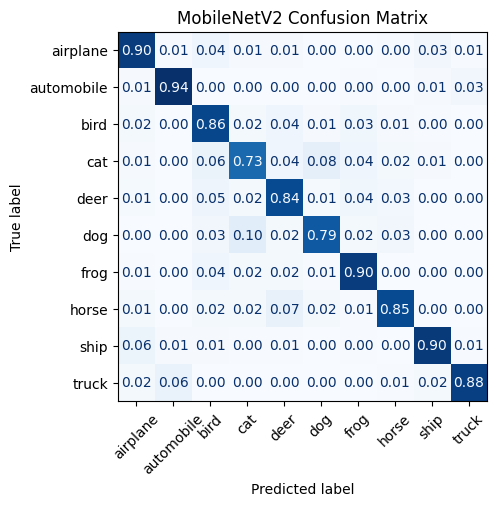


Confusion Matrix for ResNet50
  1/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step


<Figure size 600x600 with 0 Axes>

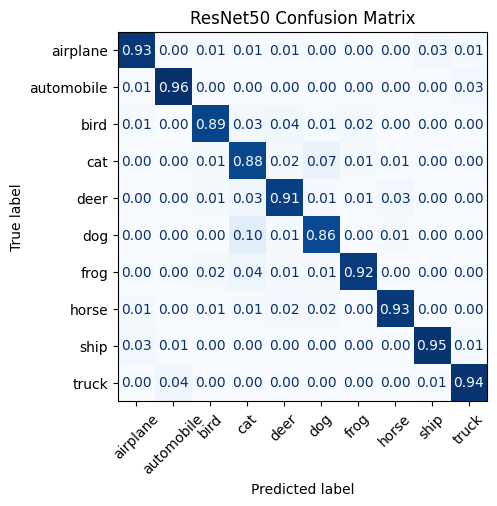


Confusion Matrix for EfficientNetB0
  2/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step


<Figure size 600x600 with 0 Axes>

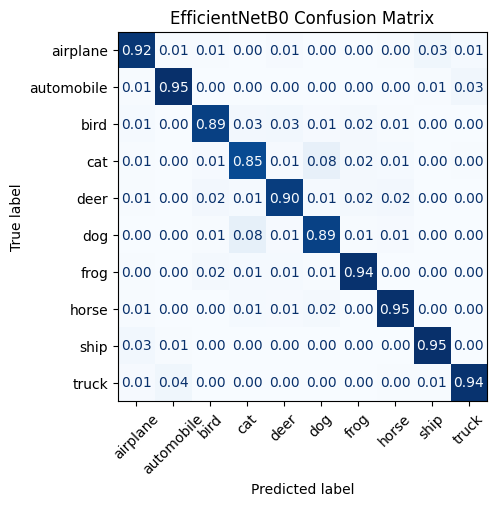


Confusion Matrix for VGG16
  1/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step


<Figure size 600x600 with 0 Axes>

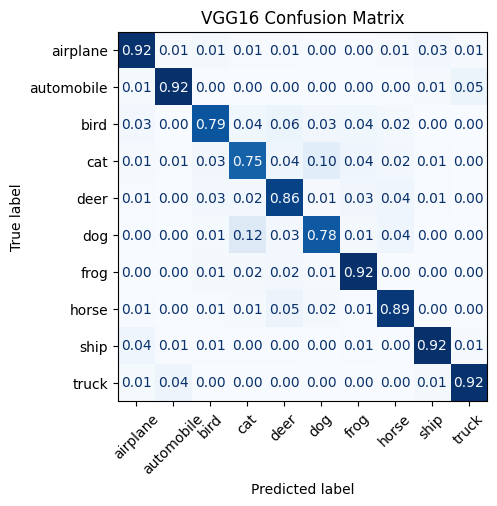

In [40]:
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

for model_name, model_fn in models_to_test.items():

    print(f"\nConfusion Matrix for {model_name}")

    # rebuild model
    model, base_model = build_transfer_model(model_name, model_fn)
    # load weights
    model.load_weights(f"{model_name}.weights.h5")

    # predict
    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred_labels, normalize='true')

    # display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(6,6))
    disp.plot(cmap="Blues", values_format=".2f", colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks(rotation=45)
    plt.show()

As we can see the most confusion happens in Dogs vs Cats classifications, so we'll display random images of those from each model predicts:

In [43]:
def get_indices_by_condition(y_true, y_pred, true_class, pred_class, max_samples=6):
    indices = np.where((y_true == true_class) & (y_pred == pred_class))[0]
    
    if len(indices) == 0:
        return []
    
    return np.random.choice(indices, min(max_samples, len(indices)), replace=False)


Evaluating model: MobileNetV2
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step


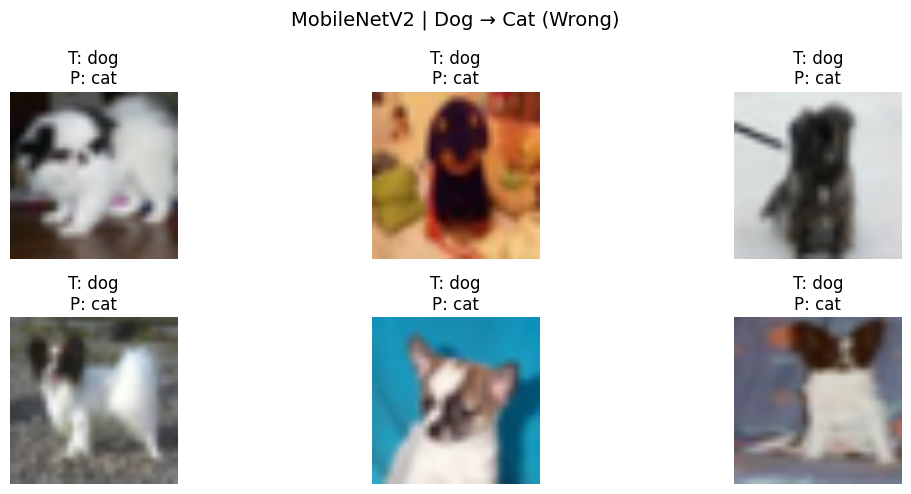

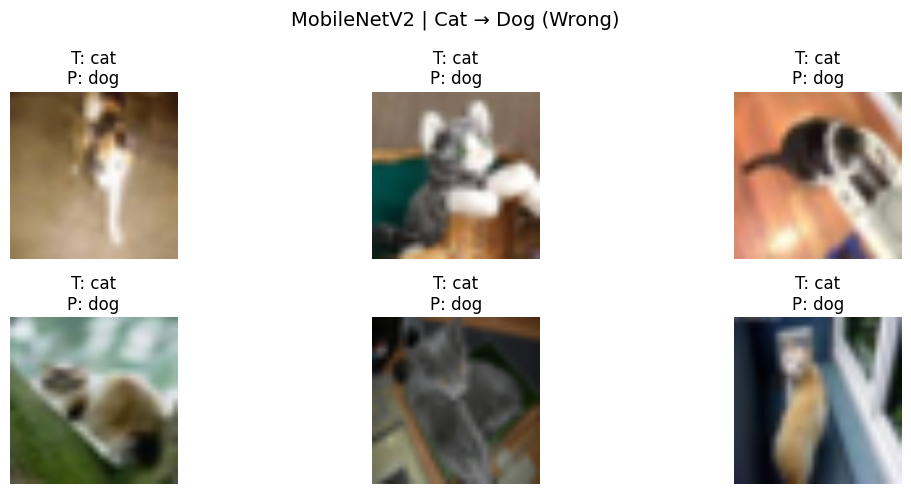

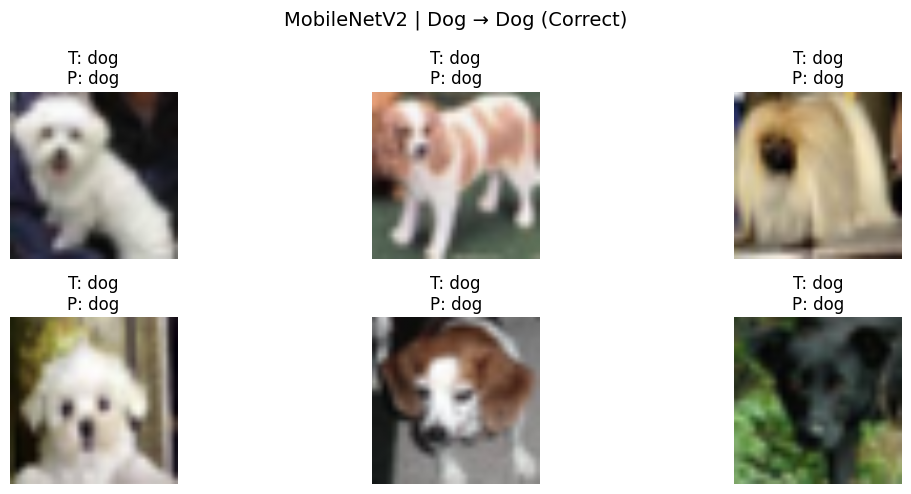


Evaluating model: ResNet50
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step


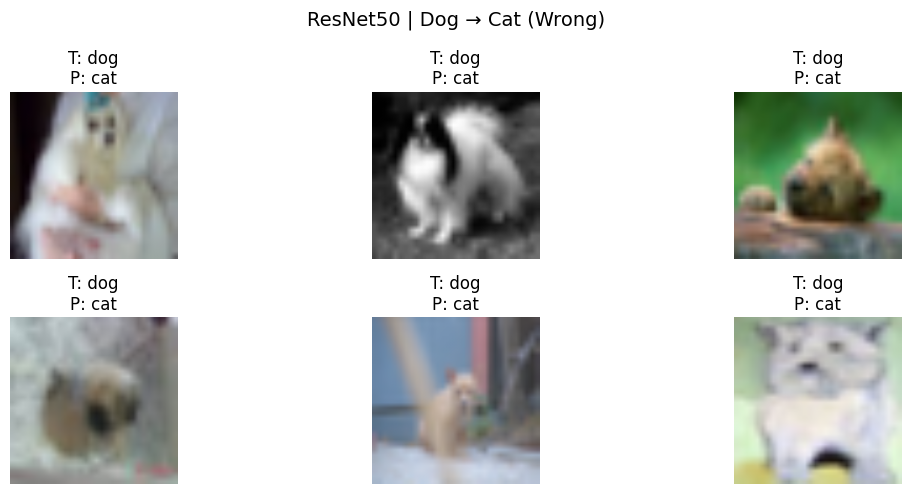

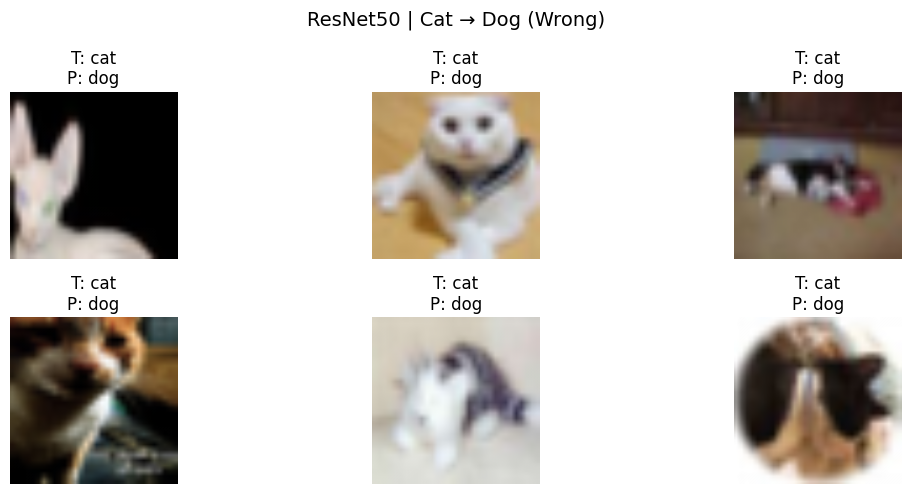

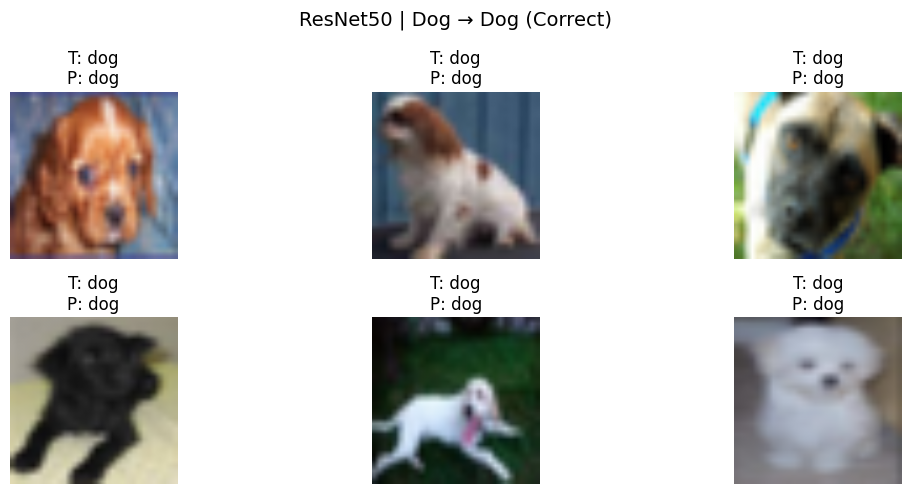


Evaluating model: EfficientNetB0
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step


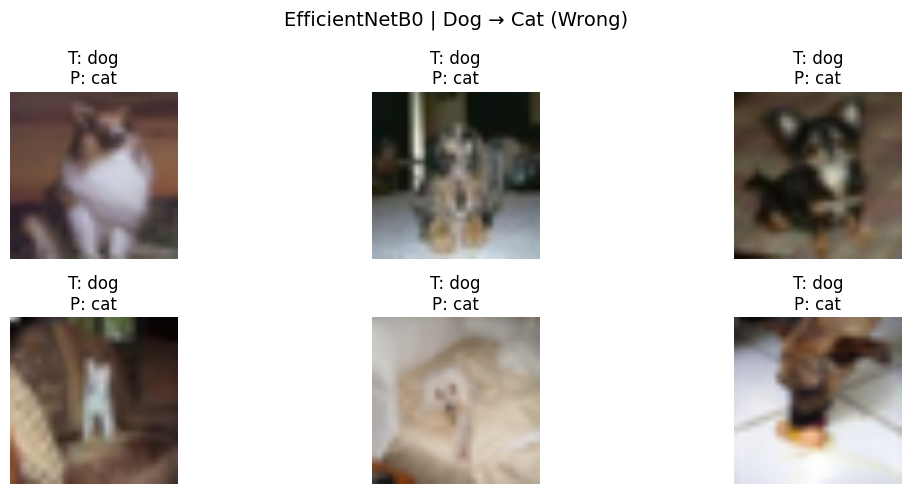

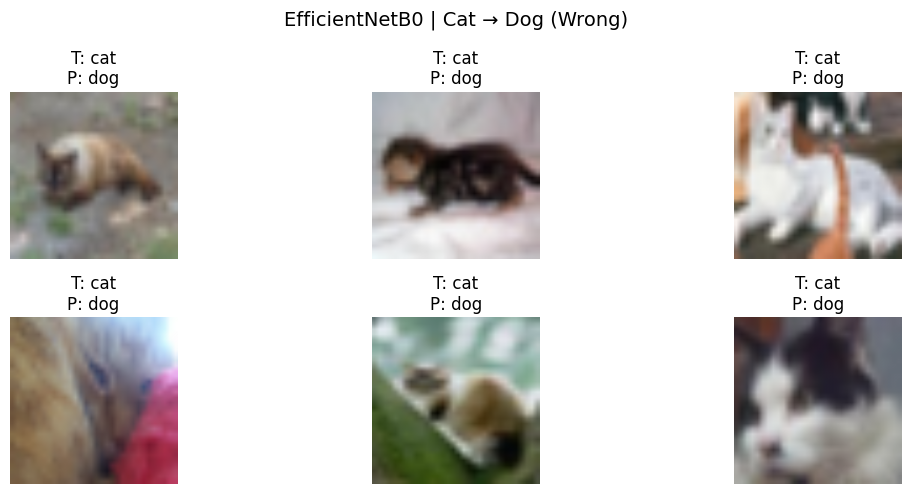

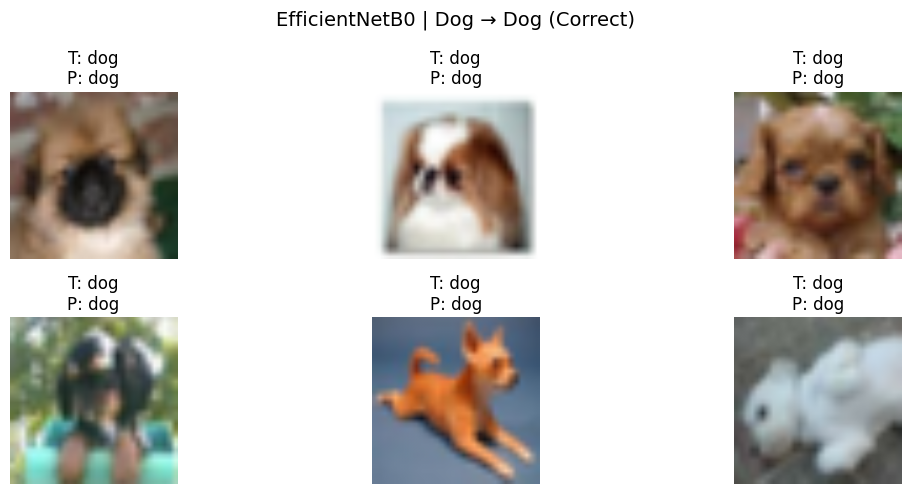


Evaluating model: VGG16
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step


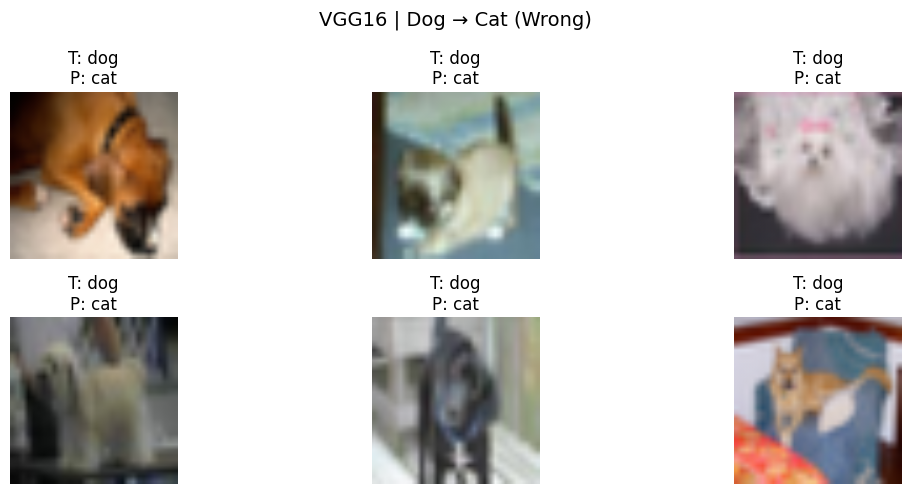

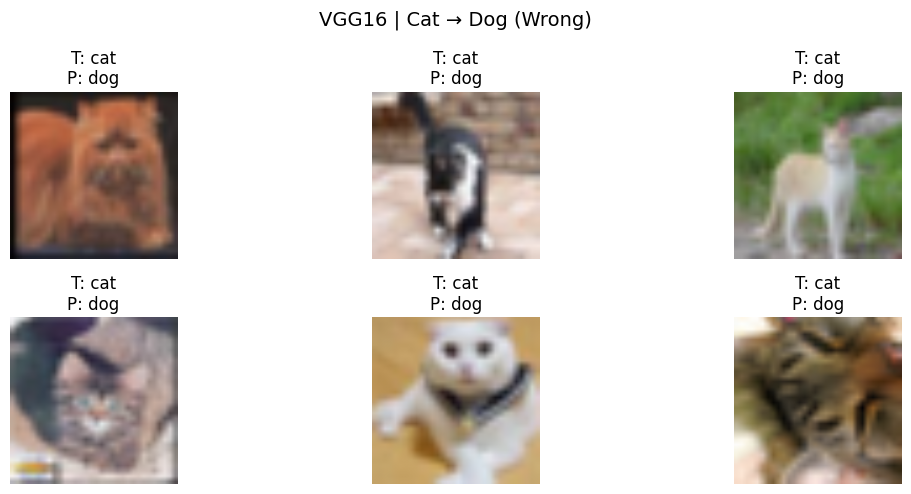

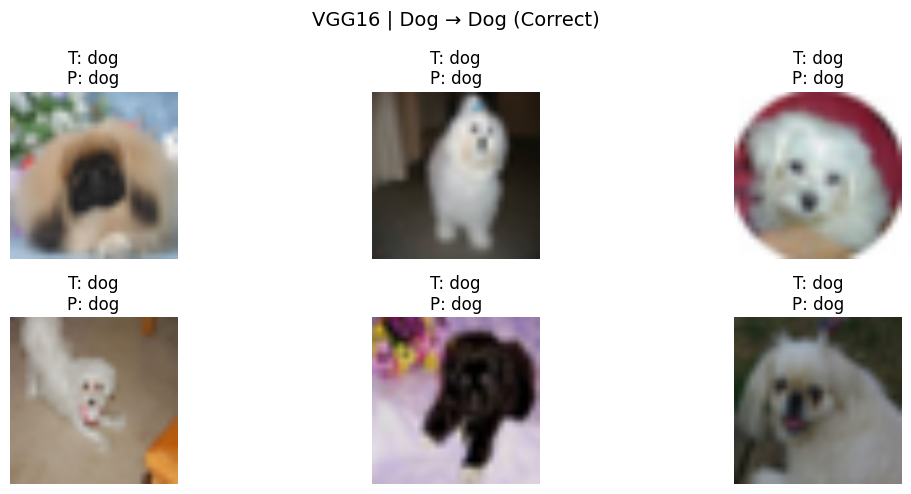

In [44]:
dog_class = class_names.index("dog")
cat_class = class_names.index("cat")

resize_layer = keras.layers.Resizing(224,224)

for model_name, model_fn in models_to_test.items():

    print(f"\nEvaluating model: {model_name}")

    model, base_model = build_transfer_model(model_name, model_fn)
    model.load_weights(f"{model_name}.weights.h5")

    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # Get specific cases
    dog_to_cat = get_indices_by_condition(y_true, y_pred_labels, dog_class, cat_class)
    cat_to_dog = get_indices_by_condition(y_true, y_pred_labels, cat_class, dog_class)
    dog_correct = get_indices_by_condition(y_true, y_pred_labels, dog_class, dog_class)

    cases = [
        ("Dog → Cat (Wrong)", dog_to_cat),
        ("Cat → Dog (Wrong)", cat_to_dog),
        ("Dog → Dog (Correct)", dog_correct)
    ]

    for title, indices in cases:

        if len(indices) == 0:
            print(f"{title}: No samples found")
            continue

        plt.figure(figsize=(12,5))
        plt.suptitle(f"{model_name} | {title}", fontsize=14)

        for i, idx in enumerate(indices):
            plt.subplot(2,3,i+1)

            img = resize_layer(X_test[idx:idx+1]).cpu().numpy()[0] / 255.0

            plt.imshow(img)
            plt.title(f"T: {class_names[y_true[idx]]}\nP: {class_names[y_pred_labels[idx]]}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

**Comparisons between those 4 transfer learning models:**

In the transfer learning stage, pretrained models (MobileNetV2, ResNet50, EfficientNetB0, and VGG16) were used with all pretrained layers frozen, and only the head was trained on CIFAR10.This way we use learned features of ImageNet without modifying them. Among the models, EfficientNetB0 achieved the best performance (~0.92 validation accuracy), followed closely by ResNet50, while MobileNetV2 and VGG16 showed slightly lower results. According to the confusion matrices we can see that the models are strong but the most confuses happens on the classifing of dogs vs cats.

### FineTuning Of The Same Models

In [29]:
# Function to unfreeze top percent of total layers of the base model for fine-tuning
def unfreeze_top_percent(base_model, percent):

    base_model.trainable = True

    total_layers = len(base_model.layers)
    n_layers = max(1, int(total_layers * percent)) # at least unfreeze 1 layer

    print(f"Total layers: {total_layers}")
    print(f"Unfreezing last {n_layers} layers ({percent*100:.0f}%)")

    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False

In [30]:
import gc # to clear GPU memory after each model training

UNFREEZE_PERCENTS = [0.1, 0.2, 0.5] # hyperparameter to examine - unfreeze top 10%, 20%, or 50% of layers
FineTune_EPOCHS = 5

for model_name, model_fn in models_to_test.items():

    for percent in UNFREEZE_PERCENTS:

        # Clear GPU memory before each model training
        gc.collect()
        torch.cuda.empty_cache()

        RESULTS_FILE = f"{model_name}_finetune_results.json"

        if os.path.exists(RESULTS_FILE):
            with open(RESULTS_FILE, "r") as f:
                results = json.load(f)
        else:
            results = []

        print("\nFine-tuning model:", model_name, "| Unfreeze Percent:", percent*100, "%")

        # build model
        model, base_model = build_transfer_model(model_name, model_fn)

        # load transfer learning weights
        model.load_weights(f"{model_name}.weights.h5")

        # unfreeze last layers
        unfreeze_top_percent(base_model, percent)

        # recompile with small learning rate - to avoid large weight updates that can destroy the pretrained features
        model.compile(
            optimizer=keras.optimizers.Adam(1e-5),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=FineTune_EPOCHS,
            batch_size=Large_BATCH_SIZE
        )

        model.summary()
        test_loss, test_acc = model.evaluate(X_test, y_test)
        print("Final test accuracy:", test_acc)
        print("Final test loss:", test_loss)

        best_val = max(history.history["val_accuracy"])

        result = {
            "model": model_name,
            "unfreeze_percent": percent,
            "accuracy": history.history["accuracy"],
            "val_accuracy": history.history["val_accuracy"],
            "loss": history.history["loss"],
            "val_loss": history.history["val_loss"],
            "val_acc": best_val,
            "test_acc": test_acc,
            "test_loss": test_loss
        }

        results.append(result)

        with open(RESULTS_FILE, "w") as f:
            json.dump(results, f)

        print(model_name, "| unfreeze ", percent*100, "% ->", best_val)


Fine-tuning model: MobileNetV2 | Unfreeze Percent: 10.0 %
Total layers: 154
Unfreezing last 15 layers (10%)
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 174ms/step - accuracy: 0.8140 - loss: 0.6536 - val_accuracy: 0.8474 - val_loss: 0.5878
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.8708 - loss: 0.3789 - val_accuracy: 0.8442 - val_loss: 0.6115
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.8945 - loss: 0.2952 - val_accuracy: 0.8524 - val_loss: 0.5520
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.9096 - loss: 0.2525 - val_accuracy: 0.8579 - val_loss: 0.5127
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.9203 - loss: 0.2202 - val_accuracy: 0.8624 - val_loss: 0.4896


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_10 (Resizing)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_3 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,329,504 (20.33 MB)

 Trainable params: 1,370,506 (5.23 MB)

...

 Total params: 41,074,784 (156.69 MB)

 Trainable params: 13,113,098 (50.02 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 26,226,198 (100.05 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.9061 - loss: 0.4069
Final test accuracy: 0.9060999751091003
Final test loss: 0.40694278478622437
VGG16 | unfreeze  50.0 % -> 0.9086999893188477


In [31]:
rows = []

for model_name, _ in models_to_test.items():
    
    file = f"{model_name}_finetune_results.json"
    
    if not os.path.exists(file):
        continue
        
    with open(file, "r") as f:
        results = json.load(f)
        
    # Find the best result based on validation accuracy
    best = max(results, key=lambda x: x["val_acc"])
    
    rows.append({
        "Model": model_name,
        "Unfreeze Percent": best["unfreeze_percent"] * 100,
        "Best Val Accuracy": best["val_acc"],
        "Final Train Accuracy": best["accuracy"][-1],
        "Final Val Accuracy": best["val_accuracy"][-1],
        "Final Loss": best["loss"][-1],
        "Final Val Loss": best["val_loss"][-1],
        "Final Test Accuracy": best["test_acc"],
        "Final Test Loss": best["test_loss"]
    })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values("Best Val Accuracy", ascending=False)

df_results

,Model,Unfreeze Percent,Best Val Accuracy,Final Train Accuracy,Final Val Accuracy,Final Loss,Final Val Loss,Final Test Accuracy,Final Test Loss
1,ResNet50,50.0,0.9370,0.993550,0.9370,0.019344,0.276799,0.9360,0.288831
2,EfficientNetB0,50.0,0.9200,0.924950,0.9200,0.252421,0.315969,0.9271,0.289936
3,VGG16,50.0,0.9087,0.987125,0.9087,0.039051,0.401807,0.9061,0.406943
0,MobileNetV2,50.0,0.8814,0.923575,0.8814,0.216212,0.423111,0.8800,0.434680


In [32]:
rows = []

for model_name, _ in models_to_test.items():

    file = f"{model_name}_finetune_results.json"

    if not os.path.exists(file):
        continue

    with open(file, "r") as f:
        results = json.load(f)

    for r in results:

        rows.append({
            "Model": model_name,
            "Unfreeze Percent": r["unfreeze_percent"] * 100,
            "Best Val Accuracy": r["val_acc"],
            "Final Train Accuracy": r["accuracy"][-1],
            "Final Val Accuracy": r["val_accuracy"][-1],
            "Final Loss": r["loss"][-1],
            "Final Val Loss": r["val_loss"][-1],
            "Final Test Accuracy": r["test_acc"],
            "Final Test Loss": r["test_loss"]
        })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values(["Final Val Accuracy", "Model"], ascending=[False, True])

df_results

,Model,Unfreeze Percent,Best Val Accuracy,Final Train Accuracy,Final Val Accuracy,Final Loss,Final Val Loss,Final Test Accuracy,Final Test Loss
5,ResNet50,50.0,0.9370,0.993550,0.9370,0.019344,0.276799,0.9360,0.288831
4,ResNet50,20.0,0.9251,0.994025,0.9251,0.019357,0.339033,0.9237,0.344358
3,ResNet50,10.0,0.9235,0.995325,0.9235,0.015865,0.346251,0.9219,0.354581
8,EfficientNetB0,50.0,0.9200,0.924950,0.9200,0.252421,0.315969,0.9271,0.289936
7,EfficientNetB0,20.0,0.9127,0.934150,0.9127,0.206231,0.363556,0.9162,0.340020
6,EfficientNetB0,10.0,0.9118,0.941600,0.9118,0.175188,0.366988,0.9109,0.358054
11,VGG16,50.0,0.9087,0.987125,0.9087,0.039051,0.401807,0.9061,0.406943
10,VGG16,20.0,0.8931,0.987750,0.8931,0.039293,0.437692,0.8902,0.462830
2,MobileNetV2,50.0,0.8814,0.923575,0.8814,0.216212,0.423111,0.8800,0.434680
9,VGG16,10.0,0.8770,0.974400,0.8756,0.077925,0.456870,0.8759,0.472301


**Conclusions and comparisons Transfer Learning vs FineTuning:**

A clear and consistent performance improvement is observed when allowing partial retraining of the pretrained models. In the Transfer Learning stage, all base layers were frozen, yielding strong baseline results. However, after applying FineTuning, especially with 50% of layers unfrozen all models achieved higher accuracies than their Transfer Learning part. ResNet50 improved to ~0.937 validation and ~0.936 test accuracy, becoming the best performer model overall. This indicates that FineTuning not only improves each model individually but also changes the relative ranking between models, allowing architectures like ResNet50 to surpass others that previously performed best under Transfer Learning. The improvement comes from adapting higher level features to CIFAR10, rather than relying solely on generic ImageNet representations. Emphasizing the importance of controlled unfreezing and low learning rates. theres a gap of 6-8% between training and validation series which show moderate overfitting but on the test series we see great performance so we can infer that on general the model did well. Overall, Transfer Learning provided a strong and efficient baseline, while FineTuning got better and improved results.